**¿QUIÉNES SON NUESTROS CLIENTES MÁS VALIOSOS? UN ENFOQUE DE CLUSTERING PARA SUPERMERCADOS**

**Por: Lenin Hernando Pérez Padilla**

**Contexto del Problema: Un Desafío de Negocio**

El equipo de marketing del Supermercado FreshMart ha notado que sus campañas publicitarias actuales, enviadas masivamente a todos los clientes, tienen un ROI (Retorno sobre la Inversión) bajo. Este gasto es ineficiente porque no considera las diferencias en el comportamiento y las necesidades de los clientes. La gerencia ha solicitado una solución para optimizar la inversión en marketing y aumentar la tasa de conversión de las promociones.
Para abordar este problema, se propone utilizar los datos de las tarjetas de membresía del supermercado, correspondientes a agosto de 2023. Este conjunto de datos, con 200 registros, contiene información valiosa sobre los clientes en un período de tiempo clave:

* Edad
* Sexo
* Ingresos Anuales
* Puntuación de Gasto (Spending Score): Una métrica interna que refleja el nivel de compromiso y el historial de compras del cliente.

La misión es clara: utilizar estas variables para segmentar la base de clientes en grupos distintos y accionables. El objetivo final es proporcionar al equipo de marketing perfiles detallados de cada grupo, junto con recomendaciones específicas, para que puedan diseñar campañas publicitarias personalizadas y de alto impacto que demuestren el valor de una estrategia data-driven.

Los datos empleados para la segmentación se tomaron del siguiente enlace: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-Python

**Exploración y limpieza de datos**

Los pasos de esta fase son:

* Analizar la distribución de cada una de las variables. 
* Buscar valores atípicos, duplicados y nulos.
* Crear gráficos de dispersión para las diferentes parejas de variables.

Con base en ello, habrá una idea de cómo se ven los clústeres antes de aplicar cualquier algoritmo.

In [1]:
#Importar bibliotecas para análisis y visualización de datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Cargar datos
df = pd.read_csv('../011-A Python Jupyter Notebook/Mall_Customers.csv', index_col='CustomerID')
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


In [3]:
#Verificar los tipos de datos de cada columna y detectar posibles valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


El dataset posee cuatro columnas (variables de entrada). El género (Gender) es de tipo texto (object). Las demás columnas son de tipo numérico. Hay 200 registros. No hay datos nulos.

In [4]:
#Eliminar datos duplicados
df = df.drop_duplicates()
df = df.dropna()
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


El dataset no tiene valores duplicados.

In [5]:
#Resumen estadístico de las columnas numéricas
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


**Interpretaciones del resumen estadístico**

*1. Columna edad (Age)*

La Edad va de 18 a 70 años, por lo que el Supermercado FreshMart tiene una base de clientes muy diversa, desde adultos jóvenes hasta personas mayores.

Por otro lado, el cliente promedio tiene 39 años, pero la mediana es de 36 años, lo cual sugiere que la mitad de los clientes son menores de 36. 

A su vez, la desviación estándar de 14 años indica que hay una buena dispersión de edades y los cuartiles confirman que hay una porción significativa de clientes de todas las generaciones.

*2. Columna ingresos (Annual Income)*

Los ingresos de los clientes oscilan entre 15K y 137K. Esto indica que el supermercado no se limita a un solo nicho demográfico, sino que atrae a clientes de un espectro económico muy diverso, desde aquellos con ingresos más modestos hasta personas con alto poder adquisitivo.

Por su parte, el promedio (60,56K) y la mediana (61,50K) son muy cercanos entre sí. Esta similitud sugiere que la distribución de los ingresos es bastante simétrica, sin valores extremos que la distorsionen.

Además, la desviación estándar (26.26K) es relativamente alta, lo que confirma que hay una gran variedad en los ingresos de los clientes. Esto justifica la necesidad de un análisis de segmentación, ya que una única estrategia de marketing no funcionará para todos.

Con respecto al 50% central, la mitad de los clientes (el rango entre el cuartil 25% y el 75%) tiene ingresos entre 41.50K y 78.00K. Este es un grupo demográfico crucial para el supermercado, ya que representan la base de clientes más grande. 

Adicionalmente, el 25% de los clientes tiene ingresos inferiores a 41.50K, mientras que el otro 25% tiene ingresos superiores a 78.00K. Estos dos grupos extremos son de particular interés para el equipo de marketing, ya que podrían requerir estrategias y promociones muy diferentes.

*3. Columna puntuación de gasto (Spending Score)*

El puntaje se extiende desde un mínimo de 1.0 hasta un máximo de 99.0. Esto confirma que la métrica está funcionando como se espera, ya que captura a clientes que gastan o están comprometidos muy poco y a aquellos que son extremadamente activos y gastan mucho.

Por otro lado, el promedio (50.2) y la mediana (50.0) son prácticamente idénticos. Esto indica que, a diferencia de otras variables, la distribución de los puntajes de gasto es altamente simétrica y balanceada. En otras palabras, hay una cantidad similar de clientes con bajo gasto, alto gasto y gasto promedio.

Por su parte, la desviación estándar (25.8) es alta, ya que representa aproximadamente la mitad del promedio. Esta alta variabilidad es la razón de ser de tu proyecto de segmentación. Confirma que la base de clientes es muy diversa en su comportamiento, haciendo que las campañas masivas sean ineficientes.

Con respecto a los clientes de bajo gasto (25%), hay una cuarta parte que tiene un puntaje de gasto de 34.75 o menos. Este grupo necesita incentivos para gastar más, como cupones o promociones por volumen.

Adicionalmente, la otra cuarta parte de los clientes (alto gasto) tiene un puntaje de gasto de 73.0 o más. Este es un segmento de "Clientes Estrella" que necesitan programas de lealtad VIP o productos exclusivos para mantener su alto compromiso.

Finalmente, los clientes promedio (alrededor de 50 en el puntaje de gasto) representan el corazón de la base de clientes. Son la mayoría y representan el comportamiento de compra más común en el Supermercado FreshMart. Ya están gastando a un nivel sostenible, no son un riesgo de abandono inminente como los de gasto muy bajo, ni están gastando al máximo como los clientes estrella. Son los más susceptibles de ser "movidos" a un segmento superior (alto gasto). Pequeños incentivos pueden hacer que su gasto aumente significativamente, ofreciendo el mejor Retorno sobre la Inversión (ROI) en esfuerzos de marketing. Para este grupo, la meta del equipo de marketing debe ser clara: incentivar un aumento en la frecuencia y/o el volumen de la compra para convertirlos en clientes de alto valor. Se sugieren como estrategias de marketing campañas de incentivo por volumen, recomendación de productos premium o programas de lealtad "tier -based" (según sus gastos).

In [6]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

['Male' 'Female']
Gender
Female    112
Male       88
Name: count, dtype: int64


***Diagrama de barras para visualizar la columna Gender***

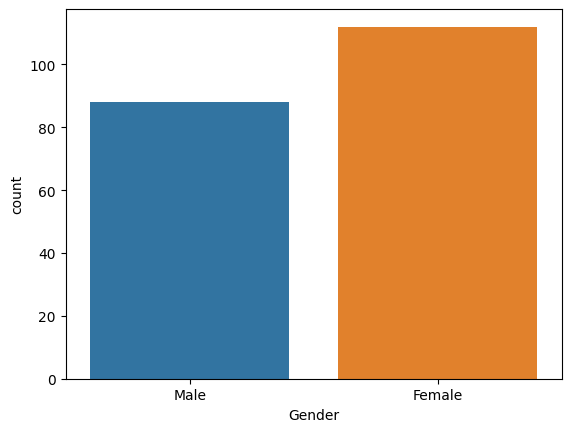

In [7]:
sns.countplot(x='Gender', data=df, hue='Gender')
plt.show()

***Diagramas de caja y bigote e histogramas***

1. Columnas Age y Gender

[Text(0.5, 1.0, 'Distribución de edades por sexo')]

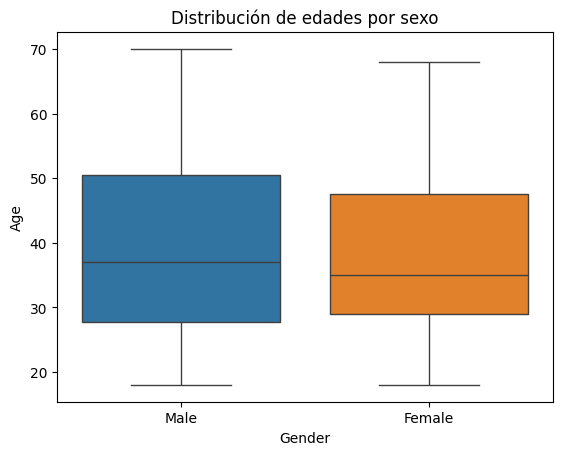

In [8]:
sns.boxplot(df, x='Gender', y='Age', hue='Gender').set(title='Distribución de edades por sexo')

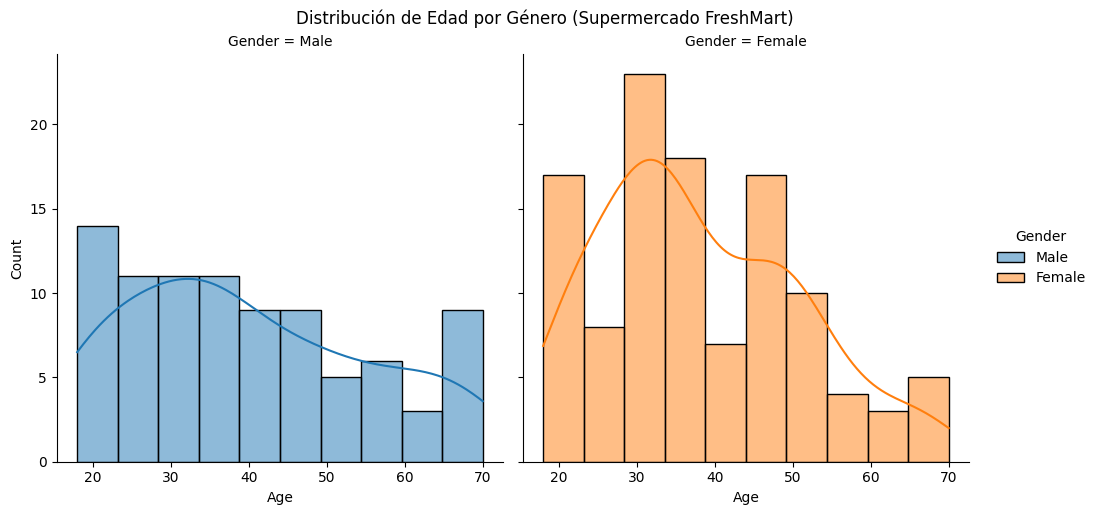

In [9]:
sns.displot(
    data=df,
    x="Age",
    col="Gender",  # Crea subgráficos por género
    hue="Gender", # Asigna un color diferente a cada subgráfico
    kind="hist", # Especifica el tipo de gráfico como histograma
    stat='count', #Para apreciar el número real de datos en cada contenedor
    bins=10, # Número de contenedores para agrupar los datos de edad
    kde=True # Añade una línea de densidad (útil para ver la forma de la distribución)
)

plt.suptitle('Distribución de Edad por Género (Supermercado FreshMart)', y=1.02)
plt.show()

2. Columnas Annual income y Gender

[Text(0.5, 1.0, 'Distribución de ingresos por sexo')]

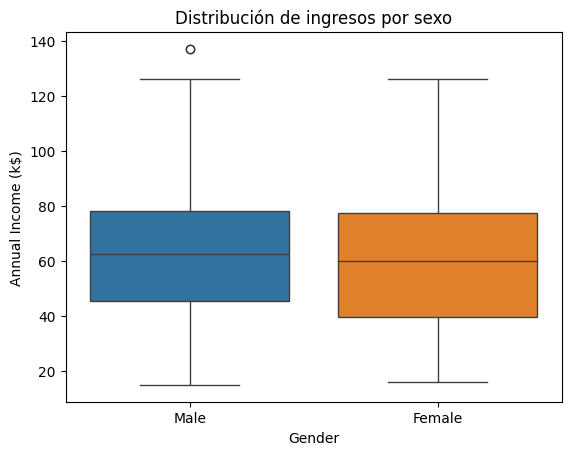

In [10]:
sns.boxplot(df, x='Gender', y='Annual Income (k$)', hue='Gender').set(title='Distribución de ingresos por sexo')

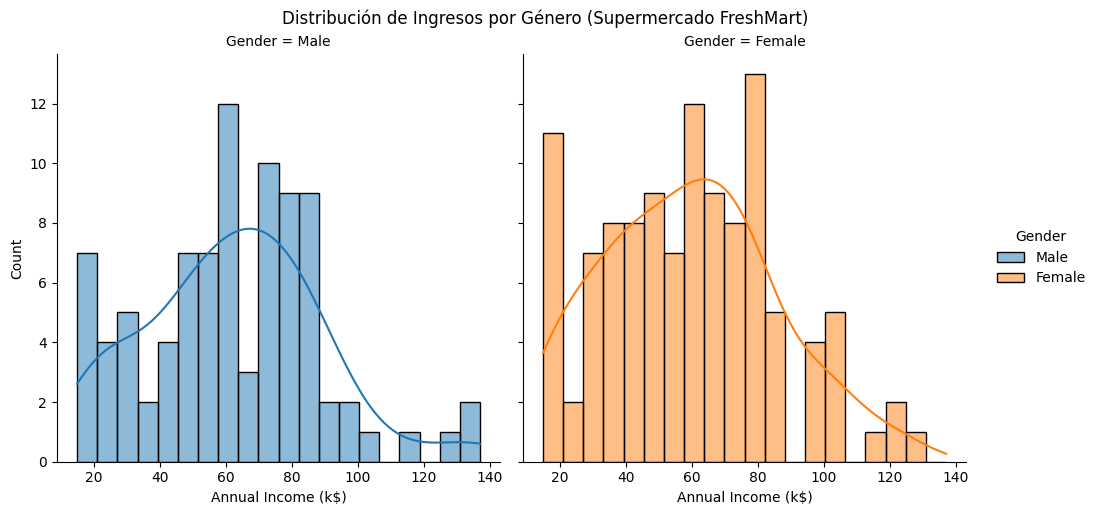

In [11]:
sns.displot(
    data=df,
    x="Annual Income (k$)",
    col="Gender",  # Crea subgráficos por género
    hue="Gender", # Asigna un color diferente a cada subgráfico
    kind="hist", # Especifica el tipo de gráfico como histograma
    stat='count', #Para apreciar el número real de datos en cada contenedor
    bins=20, # Número de contenedores para agrupar los datos de edad
    kde=True # Añade una línea de densidad (útil para ver la forma de la distribución)
)

plt.suptitle('Distribución de Ingresos por Género (Supermercado FreshMart)', y=1.02)
plt.show()

3. Columnas Spending score y Gender

[Text(0.5, 1.0, 'Distribución de puntajes por sexo')]

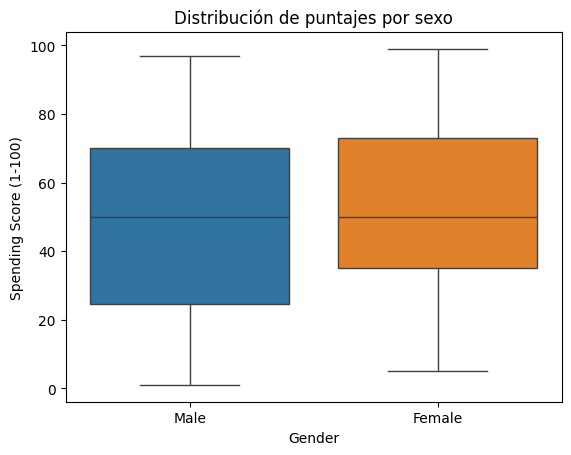

In [12]:
sns.boxplot(df, x='Gender', y='Spending Score (1-100)', hue='Gender').set(title='Distribución de puntajes por sexo')

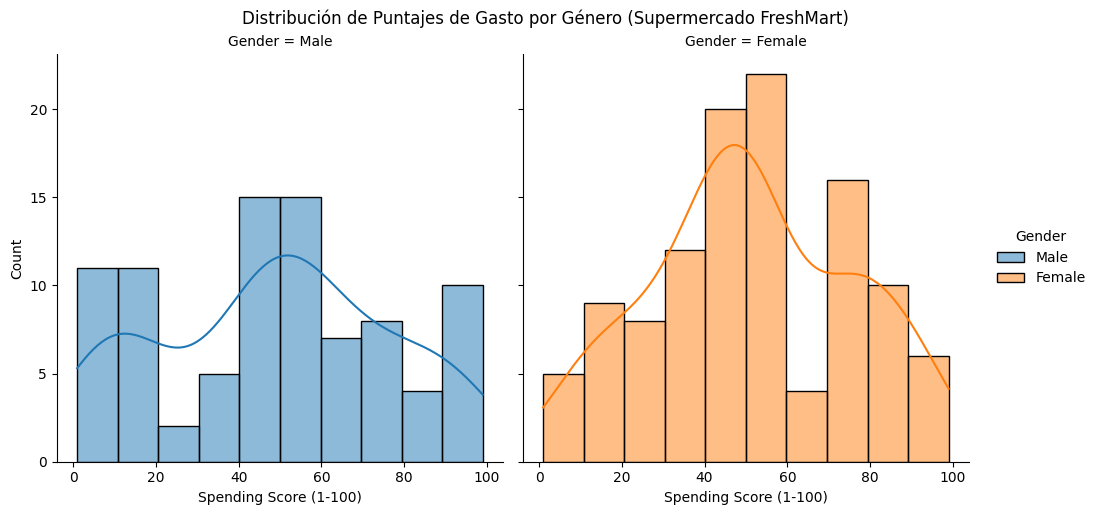

In [13]:
sns.displot(
    data=df,
    x="Spending Score (1-100)",
    col="Gender",  # Crea subgráficos por género
    hue="Gender", # Asigna un color diferente a cada subgráfico
    kind="hist", # Especifica el tipo de gráfico como histograma
    stat='count', #Para apreciar el número real de datos en cada contenedor
    bins=10, # Número de contenedores para agrupar los datos de edad
    kde=True # Añade una línea de densidad (útil para ver la forma de la distribución)
)

plt.suptitle('Distribución de Puntajes de Gasto por Género (Supermercado FreshMart)', y=1.02)
plt.show()

***Gráficos de dispersión***

1. Columnas Age y Annual income (Gender como leyenda)

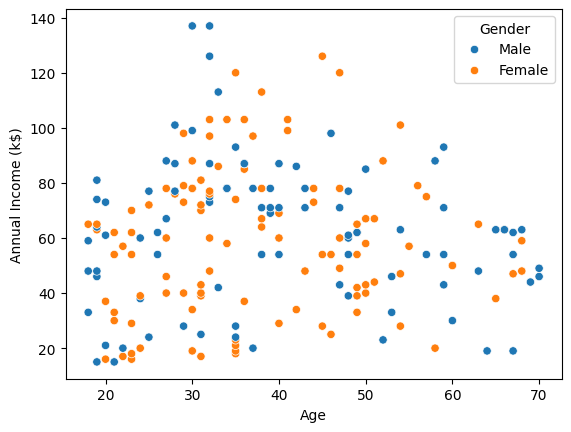

In [14]:
sns.scatterplot(x='Age', y='Annual Income (k$)', hue='Gender', data=df)
plt.show()

2. Columnas Age y Spending score (Gender como leyenda)

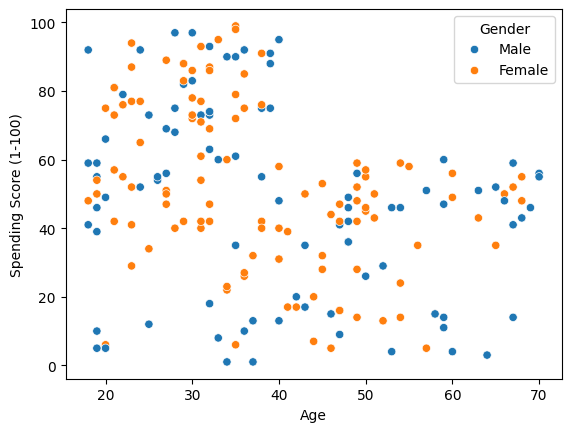

In [15]:
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Gender', data=df)
plt.show()

3. Columnas Annual income y Spending score (Gender como leyenda)

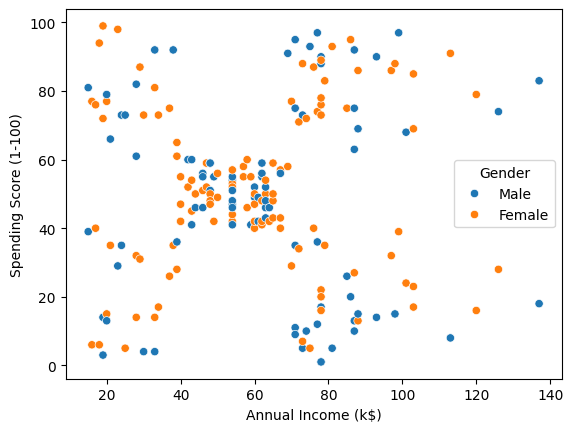

In [16]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender' ,data=df)
plt.show()

***Relaciones entre las distintas variables numéricas (Gender como leyenda)***

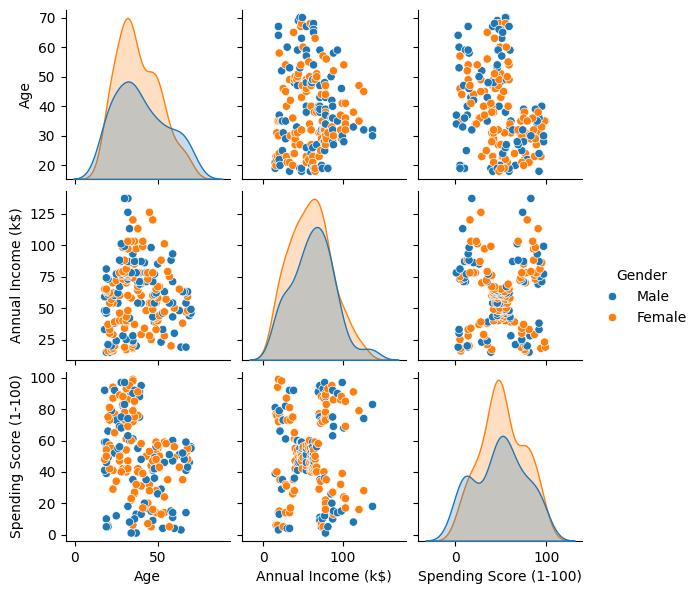

In [17]:
sns.pairplot(df, hue='Gender', height=2)

***Mapa de calor para examinar las correlaciones entre las variables***

Codificar columna Gender

In [18]:
sexo = {'Male': 0, 'Female': 1}
df['Gender'] = df['Gender'].map(sexo)

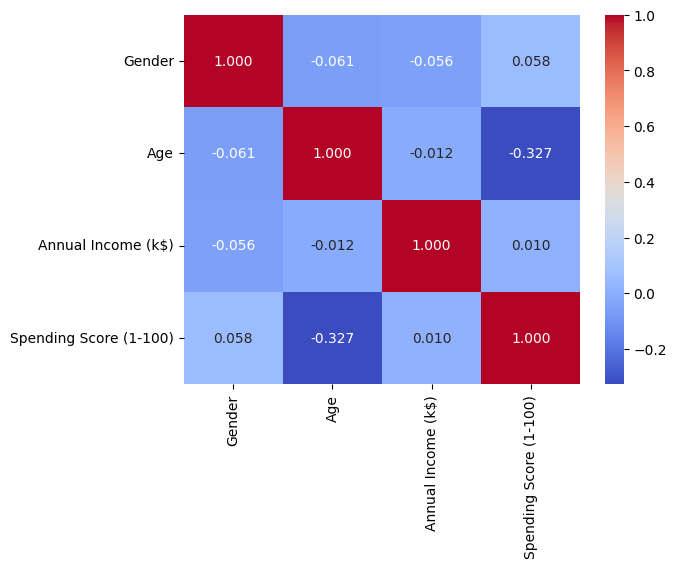

In [19]:
corr = np.corrcoef(df.T)
sns.heatmap(corr, xticklabels=df.columns, yticklabels=df.columns, cmap='coolwarm', annot=True, fmt='.3f')
plt.show()

***Gráficos de correlación de Gender con cada variable numérica***

1. Spending score vs Gender

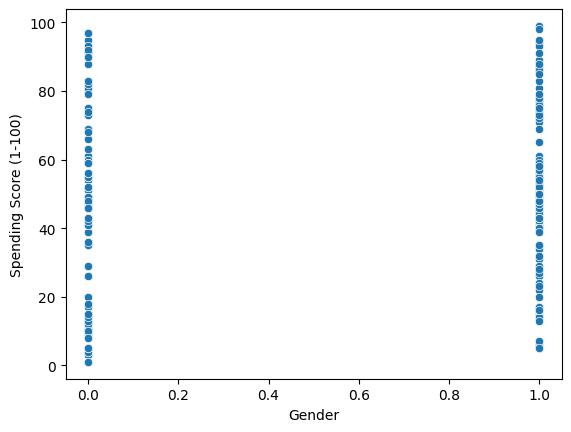

In [20]:
sns.scatterplot(x='Gender', y='Spending Score (1-100)',data=df)
plt.show()

2. Annual income vs Gender

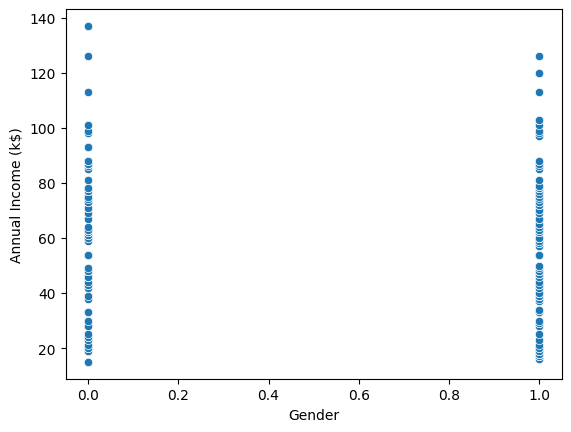

In [21]:
sns.scatterplot(x='Gender', y='Annual Income (k$)',data=df)
plt.show()

3. Age vs Gender

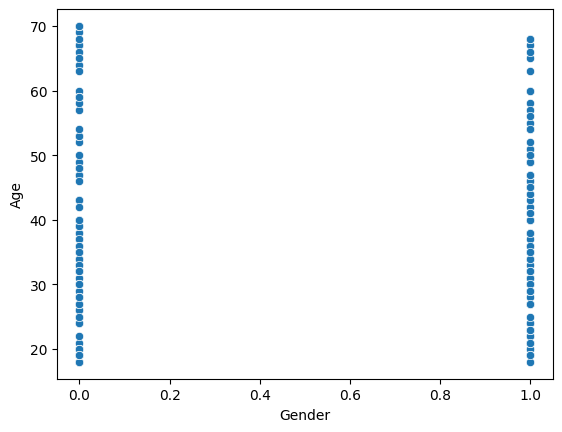

In [22]:
sns.scatterplot(x='Gender', y='Age',data=df)
plt.show()

Basado en el análisis exploratorio de datos y las correlaciones, la segmentación principal debe realizarse utilizando el Puntaje de Gasto (Spending score) y los Ingresos Anuales (Annual income) porque estas dos variables son las más críticas para definir el valor del cliente en el negocio y, lo que es fundamental para el modelo K-Means, su correlación lineal, **en valor absoluto,** es casi nula (r=0.010). Esta independencia garantiza que el modelo encuentre grupos que son distintivos tanto en su poder adquisitivo (Ingresos) como en su comportamiento de compra (Gasto). De esta forma, se identifican segmentos clave como los clientes de "alto ingreso/bajo gasto" (clientes con potencial de crecimiento) y los de "bajo ingreso/alto gasto" (clientes leales), permitiendo al equipo de marketing desarrollar estrategias de alto impacto que serían invisibles si se usaran variables altamente correlacionadas.

***Eliminar valores atípicos***

1. Columna Age

In [23]:
# Calcular promedio y desviación estándar
mean = df['Age'].mean()
std_dev = df['Age'].std()

# Calcular z-score para cada dato
z_score = (df['Age'] - mean) / std_dev

# Ajustar umbral de 3 desviaciones estándar
threshold = 3

# Remover datos atípicos del dataset
df = df[z_score <= threshold]

2. Columna Annual income

In [24]:
# Calcular promedio y desviación estándar
mean = df['Annual Income (k$)'].mean()
std_dev = df['Annual Income (k$)'].std()

# Calcular z-score para cada dato
z_score = (df['Annual Income (k$)'] - mean) / std_dev

# Ajustar umbral de 3 desviaciones estándar
threshold = 3

# Remover datos atípicos del dataset
df = df[z_score <= threshold]

3. Columna Spending score

In [25]:
# Calcular promedio y desviación estándar
mean = df['Spending Score (1-100)'].mean()
std_dev = df['Spending Score (1-100)'].std()

# Calcular z-score para cada dato
z_score = (df['Spending Score (1-100)'] - mean) / std_dev

# Ajustar umbral de 3 desviaciones estándar
threshold = 3

# Remover datos atípicos del dataset
df = df[z_score <= threshold]

In [26]:
#Conjunto de datos sin valores atípicos
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,0,19,15,39
2,0,21,15,81
3,1,20,16,6
4,1,23,16,77
5,1,31,17,40
...,...,...,...,...
196,1,35,120,79
197,1,45,126,28
198,0,32,126,74


**Preparación del modelo K-Means**

Como la correlación entre ingresos anuales (Annual Income) y puntaje de gasto (Spending Score) presenta el menor valor absoluto (r = 0.010), se opta por hacer el modelamiento K-Means con estas variables.

Por lo tanto, se prepara un nuevo dataset que excluya a las columnas sexo (Gender) y edad (Age).

Se extraen 10 datos aleatorios como muestra para probar el modelo

In [27]:
indiceMuestra = [11, 26, 42, 77, 89, 101, 128, 164, 179, 191]
muestras = pd.DataFrame(df.loc[indiceMuestra], columns = df.keys()).reset_index(drop = True)
muestras

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,67,19,14
1,0,29,28,82
2,0,24,38,92
3,1,45,54,53
4,1,34,58,60
5,1,23,62,41
6,0,40,71,95
7,1,31,81,93
8,0,59,93,14
9,1,34,103,23


Se prepara un nuevo dataset que excluye a los datos aleatorios de muestra

In [28]:
df = df.drop(indiceMuestra, axis = 0)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,0,19,15,39
2,0,21,15,81
3,1,20,16,6
4,1,23,16,77
5,1,31,17,40
...,...,...,...,...
196,1,35,120,79
197,1,45,126,28
198,0,32,126,74


In [29]:
df_new = df.drop(['Gender', 'Age'], axis=1)
df_new

,Annual Income (k$),Spending Score (1-100)
CustomerID,,
1,15,39
2,15,81
3,16,6
4,16,77
5,17,40
...,...,...
196,120,79
197,126,28
198,126,74


Este nuevo dataset se empleará para entrenar el modelo

De acuerdo con las estadísticas descriptivas y la naturaleza de cada columna, es necesario estandarizar los datos, ya que las variables están en diferentes escalas.

In [30]:
#Como el dataset no tiene valores atípicos, se opta por trabajar con StandardScaler
from sklearn.preprocessing import StandardScaler

In [31]:
#Escalado de cada subconjunto
scaler = StandardScaler()
X = df_new.copy()
X_train = scaler.fit_transform(X)

**Optimización del modelo K-Means con el método del codo y el gráfico de Silhouette**

Se importa el modelo de clusterización K-Means

In [32]:
from sklearn.cluster import KMeans

Este fragmento de código representa el método del codo para determinar el valor de k más óptimo que permite modelar el dataset. Se obtiene una lista que relaciona el número de clusters (de 1 a 10) y la inercia.

In [33]:
inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, random_state = 42)
    kmeans.fit(X_train)
    inercia.append(kmeans.inertia_)

Ahora se grafica la lista obtenida del fragmento anterior.

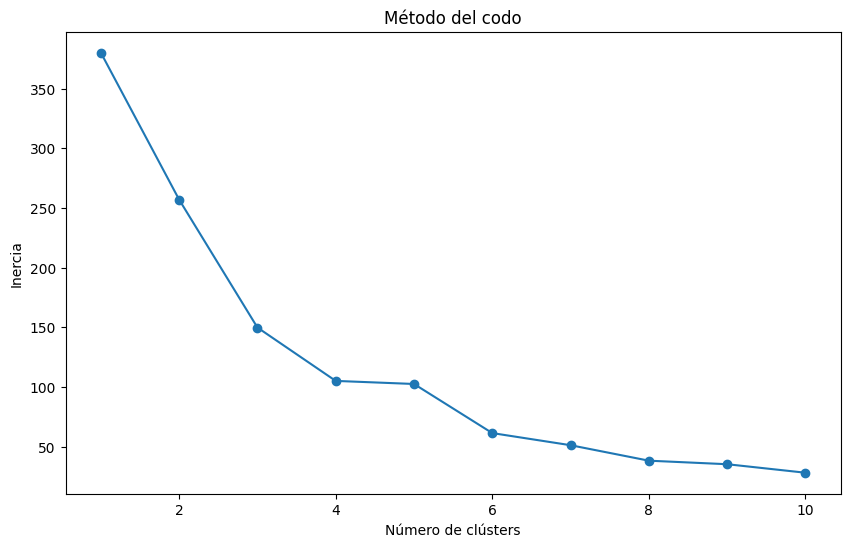

In [34]:
plt.figure(figsize = [10,6])
plt.title('Método del codo')
plt.xlabel('Número de clústers')
plt.ylabel('Inercia')
plt.plot(list(range(1, 11)), inercia, marker = 'o')
plt.show()

De acuerdo con la gráfica, se aprecian 2 codos: uno en el intervalo de 3 a 5 clusters y otro en el intervalo de 5 a 7 clusters. Para seleccionar el mejor valor de k, se va a hacer un gráfico que involucra el puntaje de Silhouette y el número de clusters.

In [35]:
#Importar la métrica del puntaje de Silhouette
from sklearn import metrics

Este fragmento de código representa una lista que relaciona el número de clusters (de 2 a 10) y el puntaje de Silhouette para determinar el valor de k más óptimo que permite modelar el dataset.

In [36]:
sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, random_state = 42)
    cluster_labels = kmeans.fit_predict(X_train)
    score = metrics.silhouette_score(X_train, cluster_labels)
    sil_scores.append(score)

A continuación se grafica la lista obtenida del fragmento anterior.

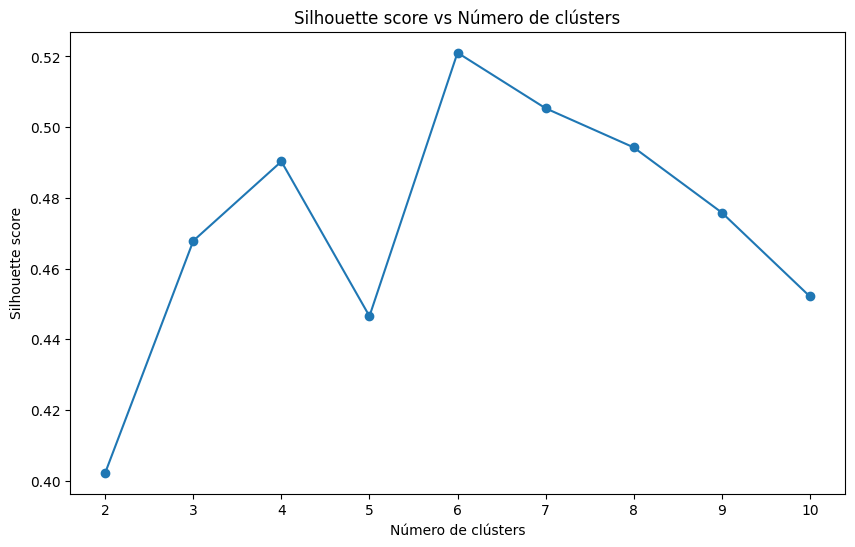

In [37]:
plt.figure(figsize = [10,6])
plt.plot(list(range(2, 11)), sil_scores, marker = 'o')
plt.title('Silhouette score vs Número de clústers')
plt.xlabel('Número de clústers')
plt.ylabel('Silhouette score')
plt.show()

De acuerdo con el método del codo y con el gráfico de Silhouette, el número óptimo de clusters es 6, con un puntaje de Silhouette de 0.52

***Entrenamiento del modelo con el número de clusters óptimo (6)***

In [38]:
kmeans = KMeans(n_clusters = 6, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
kmeans.fit(X_train)

KMeans(n_clusters=6, n_init=10, random_state=42)

***Presentación de los centroides y etiquetas***

In [39]:
centroides = kmeans.cluster_centers_
centroides

array([[-0.21282161, -0.00821191],
       [ 1.8749528 ,  1.26567078],
       [ 1.01456695, -1.27300984],
       [-1.2938923 , -1.12739789],
       [ 0.69386922,  1.23796079],
       [-1.35631893,  1.1317878 ]])

Estos valores de los centroides corresponden al conjunto de datos ya escalado. Para realizar el gráfico que incluya los datos ya segmentados y con todos los componentes necesarios, es necesario usar los valores originales de ingresos y puntajes de gasto (o sea sin estandarizar)). Por lo tanto, es necesario desescalar los valores de los centroides.

In [40]:
etiquetas = kmeans.labels_
etiquetas

array([3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3,
       5, 3, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 3, 0, 3, 5, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 4, 2, 4, 0, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 0, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 4, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1], dtype=int32)

Estos son los valores de las etiquetas para cada registro del conjunto de entrenamiento.

***Predicción con la muestra aleatoria***

In [41]:
df_muestras = muestras.drop(['Gender', 'Age'], axis=1)
df_muestras

,Annual Income (k$),Spending Score (1-100)
0,19,14
1,28,82
2,38,92
3,54,53
4,58,60
5,62,41
6,71,95
7,81,93
8,93,14
9,103,23


In [42]:
X_muestras = scaler.fit_transform(df_muestras).copy()
Y_muestra = kmeans.predict(X_muestras)
Y_muestra

array([3, 5, 5, 0, 0, 0, 4, 4, 2, 2], dtype=int32)

Estos valores son las etiquetas del conjunto de la muestra aleatoria.

**Gráficos de los clusteres obtenidos con el número óptimo de clústeres (k = 6)**

Se añaden las etiquetas obtenidas del conjunto de entrenamiento al dataset de entrenamiento sin escalar.

In [43]:
df['Cluster'] = etiquetas
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
CustomerID,,,,,
1,0,19,15,39,3
2,0,21,15,81,5
3,1,20,16,6,3
4,1,23,16,77,5
5,1,31,17,40,3
...,...,...,...,...,...
196,1,35,120,79,1
197,1,45,126,28,2
198,0,32,126,74,1


Conversión de los centroides a las escalas originales de ingresos anuales y puntaje de gasto.

In [44]:
#Utiliza el método inverse_transform() del objeto scaler para desescalar los centroides
centroides_desescalados = scaler.inverse_transform(centroides)
#Convertir centroides_desescalados a dataframe para el análisis e interpretación
df_centroides = pd.DataFrame(
    data=centroides_desescalados,
    columns=['Ingreso Anual Promedio (K$)', 'Puntaje de Gasto Promedio (1-99)']
)
#Añadir el número de clúster para la tabla de reporte (K=6)
df_centroides.index = ['Clúster ' + str(i) for i in df_centroides.index]
# Imprimir el resultado final
print(df_centroides)

           Ingreso Anual Promedio (K$)  Puntaje de Gasto Promedio (1-99)
Clúster 0                    55.179709                         56.443924
Clúster 1                   109.333616                         96.168031
Clúster 2                    87.016427                         17.003111
Clúster 3                    27.138269                         21.543800
Clúster 4                    78.697983                         95.303937
Clúster 5                    25.519011                         91.993093


Se añaden las etiquetas de la muestra aleatoria al dataset original de la muestra aleatoria sin escalar.

In [45]:
muestras['Cluster'] = Y_muestra
muestras

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,67,19,14,3
1,0,29,28,82,5
2,0,24,38,92,5
3,1,45,54,53,0
4,1,34,58,60,0
5,1,23,62,41,0
6,0,40,71,95,4
7,1,31,81,93,4
8,0,59,93,14,2
9,1,34,103,23,2


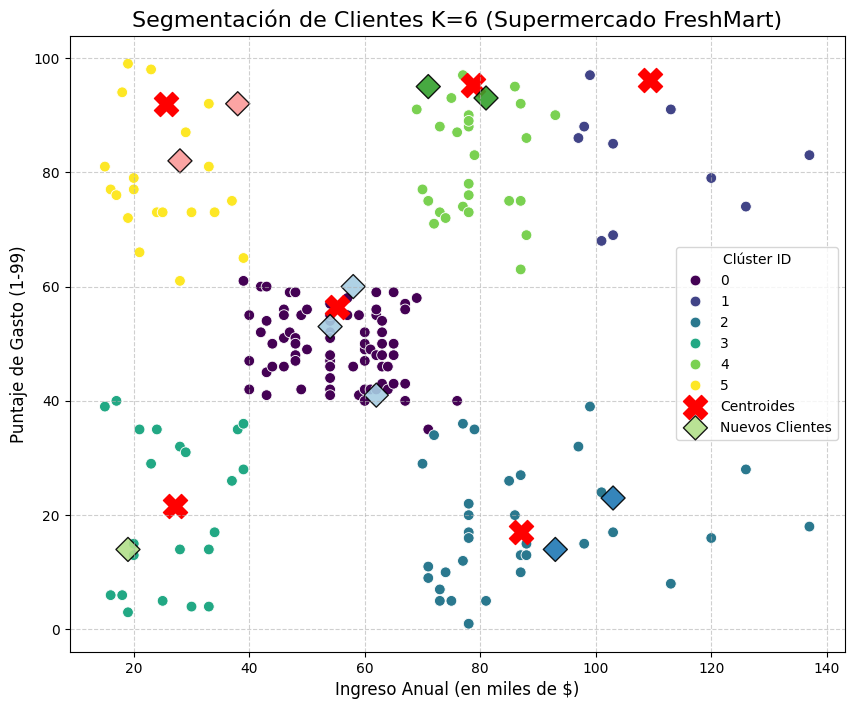

In [46]:
#Preparación del gráfico
#Los centroides desescalados se almacenan como un arreglo
array_centroides = np.array(centroides_desescalados)

#Tamaño del gráfico
plt.figure(figsize=(10, 8))

# A. Gráfico de Dispersión: conjunto de datos de entrenamiento
sns.scatterplot(
    data=df,
    x='Annual Income (k$)', #Variable que va en el eje X (Ingresos anuales)
    y='Spending Score (1-100)', #Variable que va en el eje Y (Puntaje de gasto)
    hue='Cluster',        # Color según la etiqueta de clúster
    palette='viridis',             # Paleta de colores distintivos
    s=60,                       # Tamaño de los puntos
    legend='full',              # Mostrar la leyenda de clústeres
    alpha=1                   # Transparencia para ver la densidad de puntos
)

# B. Puntos de los Centroides (los centros de cada clúster)
plt.scatter(
    x=array_centroides[:, 0],          # Ingreso Anual (Columna 0 del array)
    y=array_centroides[:, 1],          # Puntaje de Gasto (Columna 1 del array)
    s=300,                       # Tamaño grande para que se vean
    c='red',                     # Color rojo para resaltarlos
    marker='X',                  # Marcador en forma de 'X' o estrella
    label='Centroides'           #Etiquetas para los centroides
)

# C. Gráfico de Dispersión: conjunto de la muestra aleatoria
sns.scatterplot(
    data=muestras,
    x='Annual Income (k$)', #Variable que va en el eje X (Ingresos anuales)
    y='Spending Score (1-100)', #Variable que va en el eje Y (Puntaje de gasto)
    hue='Cluster', # Para que se coloreen según su nuevo clúster
    palette='Paired',      # Usar una paleta ligeramente diferente o un color fijo si quieres
    s=150,               # Tamaño más grande para destacarlos
    marker='D',          # Marcador en forma de diamante para distinguirlos
    edgecolor='black',   # Borde negro para que se vean más
    legend=False,        # No repetir la leyenda de clústeres para estos puntos
    alpha=0.9,           #Transparencia para ver la densidad de los puntos 
    label='Nuevos Clientes' # Etiqueta para la leyenda general
)

# Etiquetas, títulos y cuadrículas
plt.title(f'Segmentación de Clientes K={len(centroides)} (Supermercado FreshMart)', fontsize=16)
plt.xlabel('Ingreso Anual (en miles de $)', fontsize=12)
plt.ylabel('Puntaje de Gasto (1-99)', fontsize=12)
plt.legend(title='Clúster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [47]:
edad_promedio_cluster = df.groupby('Cluster')['Age'].mean().round(1)
print("--- Edad Promedio por Clúster ---")
print(edad_promedio_cluster)

--- Edad Promedio por Clúster ---
Cluster
0    43.3
1    32.2
2    40.3
3    44.2
4    32.7
5    25.2
Name: Age, dtype: float64


In [48]:
proporcion_mujeres = df.groupby('Cluster')['Gender'].mean().round(2) * 100
proporcion_hombres = 100 - proporcion_mujeres
df_proporciones = pd.DataFrame({
    'Mujeres (%)': proporcion_mujeres,
    'Hombres (%)': proporcion_hombres
})
print("\n--- Proporción de Sexo por Clúster ---")
print(df_proporciones)


--- Proporción de Sexo por Clúster ---
         Mujeres (%)  Hombres (%)
Cluster                          
0               57.0         43.0
1               60.0         40.0
2               47.0         53.0
3               64.0         36.0
4               52.0         48.0
5               65.0         35.0


**Estrategias de marketing**

De acuerdo con el gráfico  se aprecia una clara separación de los grupos en el plano Puntaje de Gasto vs. Ingreso Anual que valida la decisión de usar estas dos variables y demuestra el éxito del modelo K-Means. La estructura visible del gráfico revela seis tipos de clientes con estrategias de marketing bien diferenciadas, que se sustentan con los cálculos de promedios y proporciones agrupando por cluster:

***- Clúster 0:*** Su posición en el gráfico es *ingreso medio y gasto medio.* Este cluster representa a los *"Clientes Estándar o de Oportunidad".* Ya están gastando a un nivel saludable, pero no están maximizando su potencial ni demostrando una lealtad extrema. Tienen un poder adquisitivo cómodo, pero no lujoso (promedio de ingresos de 55.2 k). Son sensibles a las ofertas de valor, no necesariamente al precio más bajo. Están comprometidos, pero solo lo necesario. Suelen comprar lo que necesitan sin buscar activamente ofertas de la tienda (promedio de puntaje de 56.4). Es un grupo maduro y establecido, probablemente con familias. Sus patrones de compra son estables y predecibles (promedio de edad de 43.3 años). Con respecto a la proporción del sexo (57% mujeres y 43% hombres), ésta coincide con la distribución general de la población del supermercado, haciendo que este grupo sea el más representativo del cliente promedio. Este grupo no destaca por ser extremo en ninguna dimensión, lo que lo convierte en el segmento de mayor volumen y mayor oportunidad de crecimiento del Supermercado FreshMart. La estrategia de marketing para este grupo no debe ser la retención (como con los VIP) ni la atracción por precio (como con los frugales), sino el *Crecimiento (Upsell):*

- Aumento del Volumen de Compra: Diseñar ofertas que los incentiven a llenar más el carrito, como "Gasta $60 y obtén un 15% de descuento en tu próxima visita", empujándolos fuera de su umbral de gasto habitual.

- Activación de Categorías: Usar su edad y estabilidad para dirigir promociones de categorías de alto margen (productos gourmet, vinos, kits de comida pre-preparada), sugiriendo que "prueben algo nuevo" con un pequeño descuento.

- Ambición de Lealtad: Mostrarles que están a solo un pequeño aumento de gasto de alcanzar el siguiente nivel de membresía (los Clústeres Estrella), creando una "ambición de VIP" para motivar un mayor compromiso.

***- Clúster 1:*** Su posición en el gráfico es *ingreso superior y gasto superior.* Este cluster representa a los *Clientes VIP/Élite.* Son la base de la rentabilidad actual del negocio. La élite absoluta. Máximo gasto (puntaje promedio de 96.2), máximo ingreso (promedio ingresos 109.3 k). Son los embajadores de la marca. Capacidad económica sin restricciones. Estos clientes pueden comprar productos premium y de alto margen. Máximo Nivel de Compromiso y Lealtad. Son el grupo que gasta más y con mayor frecuencia en el supermercado. Es un grupo de profesionales jóvenes y exitosos (promedio de edad de 32.2 años), lo cual implica un potencial de ingreso y gasto que seguirá creciendo. Con respecto al sexo, este grupo está ligeramente dominado por mujeres (60% mujeres y 40% hombres), lo que puede guiar el contenido y las promociones hacia categorías de mayor interés femenino (productos gourmet, bienestar, hogar). La estrategia de negocio se basa en *Super-Retención.* El principal objetivo es maximizar su valor de por vida (Customer Lifetime Value - CLV) para mantenerlos durante un período prolongado, evitando que abandonen la tienda y fomentando relaciones a largo plazo. 

- Programa de Lealtad Exclusivo: Deben recibir el más alto nivel de beneficios: descuentos de alto valor, acceso anticipado a productos y eventos privados. El enfoque debe ser hacer que la competencia se sienta irrelevante.

- Marketing Personalizado y Expresivo: Dado que son jóvenes y exitosos, responderán bien a la comunicación que reconozca su estatus. Enviar recomendaciones hiper-personalizadas de productos de moda o de estilo de vida que coincidan con su alto nivel de ingreso.

- Monitoreo de Churn (Abandono): Son tan valiosos que la pérdida de uno solo tiene un impacto significativo. Monitorear cualquier reducción en la frecuencia de compra para activar una campaña de recuperación inmediata y personalizada.

***- Clúster 2:*** Su posición en el gráfico es *ingreso alto y gasto bajo.* Este cluster corresponde a *Clientes con Potencial Dormido.* Es un segmento de alto valor potencial, pero que actualmente ofrece un bajo retorno sobre la inversión (ROI). Tienen un alto poder adquisitivo (promedio de ingresos de 87.0 k). No están limitados por el precio, lo que significa que su bajo gasto es una elección, no una necesidad. Bajo compromiso con la marca (puntaje promedio de 17.0). Es probable que compren muy esporádicamente, compren solo artículos esenciales, o que dividan sus compras principales con un competidor. Son clientes establecidos. Su promedio de edad (40.3 años) sugiere un patrón de gasto estable, por lo que su bajo puntaje de gasto es una señal de alerta y una gran oportunidad. La distribución de género es equilibrada (47% mujeres y 53% hombres), lo que sugiere que las estrategias deben ser universales en contenido, evitando sesgos demográficos. Este cluster representa la oportunidad de crecimiento más rentable del supermercado. La pregunta clave es *¿Por qué clientes que pueden gastar, no lo hacen aquí?* La meta es convertir este potencial en gasto real. La estrategia de negocio se basa en *Activación del Gasto:*

- Marketing de Valor, No de Descuento: Evitar cupones por porcentaje. Ofrecer valor percibido: "Envío a domicilio gratis por un año" o "Acceso a productos de edición limitada". Esto capitaliza su ingreso sin devaluar la marca.

- Campañas de "Compromiso": Enviar comunicación personalizada preguntando: "¿Qué tipo de productos de alto valor le gustaría ver en FreshMart?". Esto los involucra y te da insights sobre lo que están comprando en otro lugar (ej., carne gourmet, productos orgánicos específicos).

- Monitoreo de Frecuencia: El foco debe estar en aumentar la frecuencia de visita, no necesariamente el tamaño del carrito. Incentivos como "Compra dos veces este mes y obtén un beneficio premium" funcionan mejor que los descuentos masivos.

***- Clúster 3:*** Su posición en el gráfico es *ingreso bajo y gasto bajo.* Su caracterísitica principal corresponde a *Clientes Frugales/Básicos.* Este grupo se caracteriza por tener bajos recursos y, por lo tanto, un bajo compromiso de gasto con el supermercado. Están limitados por el precio (promedio de ingresos de 27.1 k). Estos clientes no tienen capacidad para gastos discrecionales; sus decisiones de compra se basan en la necesidad y el valor. Bajo compromiso de gasto (puntaje promedio de 21.5). Solo compran lo estrictamente necesario y son extremadamente sensibles a las fluctuaciones de precios. El promedio de edad (44.2 años) indica que se trata de un grupo maduro con patrones de compra establecidos, lo que significa que el bajo gasto no es temporal, sino una decisión económica estable. Con respecto al género, es un segmento dominado por mujeres (64% mujeres y 36%hombres), lo que puede guiar el marketing hacia artículos de primera necesidad o de alto consumo doméstico. La estrategia de negocio se basa en *Atracción por precio:*

- Estrategia de Precio Directo: El marketing debe enfocarse en los descuentos más agresivos y en las marcas de valor (marcas propias del supermercado o genéricas). Los programas de "Ahorro al Por Mayor" pueden atraer a este segmento.

- Foco en la Frecuencia: Aunque el valor del carrito será bajo, el objetivo es maximizar la frecuencia de sus visitas, asegurando que cubran sus compras básicas en el supermercado FreshMart en lugar de ir a un competidor de descuento.

- Baja Inversión en Personalización: Debido a su bajo valor de por vida proyectado, se recomienda automatizar y estandarizar las campañas para este grupo. La inversión en marketing personalizado debe ser mínima, a favor de la promoción masiva de descuentos.

Este segmento es importante para el volumen de tráfico de la tienda y para mantener precios competitivos percibidos en el mercado.

***- Clúster 4:*** Su posición en el gráfico es *ingreso alto y gasto superior.* Este grupo corresponde a *Clientes Estrella.* Aunque tiene un ingreso promedio ligeramente menor que el Clúster 1, su puntaje de gasto es igual de alto, y su posición en el gráfico nos permite diferenciarlo como un grupo de máxima lealtad. Fuerte poder adquisitivo (promedio de ingresos de 78.7 k), aunque ligeramente inferior al Clúster 1. Esto significa que maximizaron su gasto en la tienda. Su alta intensidad de consumo (puntaje promedio de 95.3) indica que han concentrado casi todo su gasto de supermercado en FreshMart. Es un grupo joven y de alto potencial. Su promedio de edad (32.7 años) es casi idéntico al del Clúster 1, lo que sugiere una mentalidad de consumo similar: profesionales que valoran la calidad y la conveniencia. La distribución de género es casi perfectamente equilibrada (52% mujeres y 48% hombres), lo que simplifica la creación de contenido de marketing de estilo de vida. La estrategia de negocio se basa en *Retención máxima:* 

- Marketing de Agradecimiento: El foco no es vender más, sino mantenerlos. Implementar campañas que no sean transaccionales: enviar regalos de cumpleaños de alto valor, invitaciones a eventos patrocinados o encuestas exclusivas sobre los productos que quieren ver.

- Programa Anti-Churn (Anti-Abandono): Son el grupo más sensible a la competencia. Cualquier descenso en la frecuencia de compra debe activar una respuesta inmediata y personal de servicio al cliente, ofreciendo una solución premium para el inconveniente.

- Embajadores de Marca: Identificar a estos clientes como potenciales participantes en un programa de referidos de élite. Ofrecerles beneficios excepcionales por traer nuevos clientes de alto valor, capitalizando su alta lealtad.

Aunque el clúster 1 y el clúster 4 son similares, el negocio los puede diferenciar por ingreso. Si el clúster 1 tiene $109K, lo ven como más dinero. Se puede argumentar que el clúster 4 es el cliente más "eficiente" de la tienda, pues gasta más de su ingreso aquí.

***- Clúster 5:*** Su posición en el gráfico es *ingreso bajo y gasto alto.* Este segmento corresponde a *Clientes Leales/Dedicados.* Son los clientes que obtienen el máximo valor de su dinero en el supermercado. Sus recursos son muy limitados (promedio de ingresos de 25.5 k). Esto significa que cada dólar gastado es una decisión consciente y crítica.Muestran una lealtad extrema, invirtiendo la mayor parte de su escaso presupuesto de gasto en FreshMart (puntaje promedio de 92.0). Es el segmento más joven (promedio de edad de 25.2 años). Suu alto gasto puede deberse a que están comprando para la familia o a que no tienen cargas financieras mayores. Este patrón puede cambiar a medida que envejecen. Con respecto al sexo, está claramente dominado por mujeres (65% mujeres y 35% hombres), por lo que la estrategia debe apelar a las necesidades de las jóvenes o de las que gestionan el hogar con presupuestos limitados. La estrategia de negocio se basa en *Lealtad inquebrantable,* ya que son el testimonio de que el supermercado ofrece los precios y la conveniencia que necesitan.

- Reconocimiento de Lealtad: No se trata solo de descuentos, sino de respeto por su presupuesto. Implementar un programa de lealtad que les otorgue beneficios exclusivos sin requerir un gasto mayor (ejemplo, acceso anticipado a ofertas, cashback directo, o muestras gratuitas de productos esenciales).

- Marketing de Esenciales: Enfocar la comunicación en ofertas de "canasta básica" y productos de marca propia que son clave para su ahorro. Asegurarles que FreshMart es su socio en el ahorro.

- Monitoreo de Cambios: Dado que son jóvenes, su patrón de ingreso podría mejorar rápidamente. Si su ingreso aumenta, hay que monitorear si su gasto cambia. Si su ingreso (en la data histórica) sube y su puntaje de gasto se mantiene alto, se están moviendo al Clúster Estrella y deben ser promocionados a una categoría de upsell.

**Conclusiones**

- Las variables que permiten una segmentación adecuada con el modelo K-Means son los ingresos anuales y el puntaje de gasto, debido a su casi nula correlación.

- El modelo K-Means genera 6 clusteres claramente definidos y con base en ellos se establecen estrategias de marketing para cada uno.

- *El cluster 0,* que corresponde a los *clientes estándar*, adopta la estrategia del *crecimiento,* con el fin de aumentar el volumen de compra, activar las promociones de categorías y generar lealtad.

- *El cluster 1,* que corresponde a los *clientes VIP,* comprende la estrategia *super-retención,* que está compuesta por un programa de lealtad exclusivo, marketing personalizado y expresivo, y un monitoreo de churn para activar campañas de recuperación.

- *El cluster 2,* que corresponde a los *clientes con potencial dormido,* requiere la estrategia *activación del gasto* para ofrecer marketing de valor (sin descuentos), campañas de compromiso y aumentar su frecuencia de visita.

- *El cluster 3,* que corresponde a los *clientes frugales,* necesita la estrategia *atracción por precio,* con el fin de enfocarse en programas de ahorro, maximizar la frecuencia de sus visitas y promover descuentos atractivos.

- *El cluster 4,* que corresponde a los *clientes estrella,* emplea la estrategia *retención máxima,* con el propósito de mantenerlos, evitar abandonos dado que son sensibles a la competencia y ofrecerles beneficios excepcionales por su lealtad.

- *El cluster 5,* que corresponde a los *clientes leales,* usa la estrategia *lealtad inquebrantable,* que requiere respetar su presupuesto, enfocar su comunicación en ofertas de canasta básica y monitorear sus comportamientos de compra para promoverlos al segmento estrella (cluster 4).